##### Author: Jimin Kim (jk55@uw.edu)
##### Version 1.5.0

# Lab 5 Report

## Group Members: Sam Decker, Dadhich Sparsh

In [44]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

%matplotlib inline
##import dynworm as dw

In [45]:
from IPython.display import Image as ipyimage #For displaying images in colab jupyter cell

## Exercise 1: Visualize brain connectomes

In [47]:
# Load synaptic connectome and neuron classes

celegans_syn_conn_pd = pd.read_excel('connectome_syn.xlsx')
celegans_syn_conn_np = np.array(celegans_syn_conn_pd)

# Classes are ordered according to the neurons' order in synaptic connectome
neuron_classes = np.load('neuron_classes.npy')

In [48]:
# Adjacency matrix of the first 10 neurons
print(celegans_syn_conn_np[:10, :10])

[[0 0 0 3 0 0 7 0 0 0]
 [0 0 1 0 7 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 2 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 2 0 0 0 0 1]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


In [49]:
# Neuron classes of the first 10 neurons
print(neuron_classes[:10])

['sensory' 'sensory' 'sensory' 'sensory' 'sensory' 'sensory' 'sensory'
 'sensory' 'sensory' 'sensory']


In [50]:
def vis_conn(syn_conn, neuron_classes):
    # The function should output a 1 x 3 subplot
    # For each subplot, make sure to set plt.ylim(len(sub_adjacency_matrix), 0) so that first row starts with neuron 0
    # Add appropriate x,y labels for each subplot (e.g. sensory vs sensory, inter vs inter, etc)

    ## create a boolean array, where elements are true only when the corresponding
    ## value is of the given neuron class
    sensory_mask = neuron_classes == 'sensory'
    inter_mask = neuron_classes == 'inter'
    motor_mask = neuron_classes == 'motor'

    ## create submatrices by selecting the rows corresponding to the given
    ## neuron class and then selecting the colums from the resulting submatrix
    ## that are likewise, using slicing syntax
    sensory_conn = syn_conn[sensory_mask][:, sensory_mask]
    inter_conn = syn_conn[inter_mask][:, inter_mask]
    motor_conn = syn_conn[motor_mask][:, motor_mask]

    # Set up a 1x3 subplot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Sensory vs Sensory
    axes[0].imshow(sensory_conn, cmap = 'Greys', vmin = 0, vmax = 1)
    axes[0].set_title('Sensory', fontsize = 20)
    axes[0].set_ylabel('Sensory', fontsize = 20, rotation = 270, labelpad = 20)
    axes[0].yaxis.set_label_position("right")
    axes[0].set_ylim(len(sensory_conn), 0)

    # Inter vs Inter
    axes[1].imshow(inter_conn, cmap = 'Greys', vmin = 0, vmax = 1)
    axes[1].set_title('Inter', fontsize = 20)
    axes[1].set_ylabel('Inter', fontsize = 20, rotation = 270, labelpad = 20)
    axes[1].yaxis.set_label_position("right")
    axes[1].set_ylim(len(inter_conn), 0)

    # Motor vs Motor
    axes[2].imshow(motor_conn, cmap = 'Greys', vmin = 0, vmax = 1)
    axes[2].set_title('Motor', fontsize = 20)
    axes[2].set_ylabel('Motor', fontsize = 20, rotation = 270, labelpad = 20)
    axes[2].yaxis.set_label_position("right")
    axes[2].set_ylim(len(motor_conn), 0)

    plt.show()



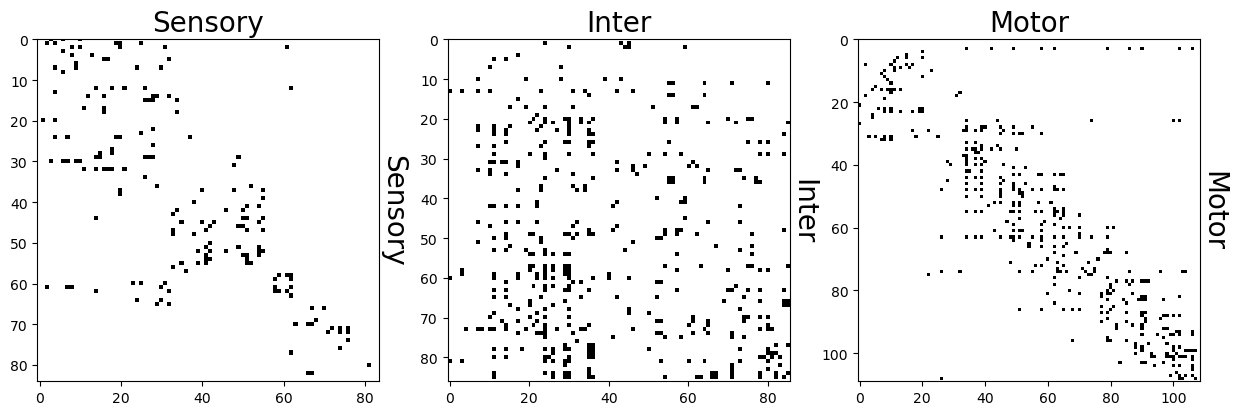

In [51]:
# Test your function here

vis_conn(syn_conn = celegans_syn_conn_np, neuron_classes = neuron_classes)

## Exercise 2: Locating the most connected vertices

In [53]:
# Load the synaptic connectome and sample social network

syn_conn_pd = pd.read_excel('connectome_syn.xlsx')
syn_conn_np = np.array(syn_conn_pd)

social_network_sample_pd = pd.read_excel('social_network_sample.xlsx')
social_network_sample_np = np.array(social_network_sample_pd)

In [54]:
def find_hub_vertices(adj_mat, num_vertices):

    # YOUR CODE HERE
    ## for a 2-D array, np.sum will return a 1D array of the sum over columns
    ## (in-degree) with axis = 0 and the sum of rows (out-degree) with axis = 1
    unsorted_indegree_list = np.sum(adj_mat, axis = 0);
    unsorted_outdegree_list = np.sum(adj_mat, axis = 1);
    #print(unsorted_indegree_list)
    #print(unsorted_outdegree_list)

    ## generate tuples to store (degree, index) pairs over each index of the unsorted list
    indegree_tuples = [(unsorted_indegree_list[i], i) for i in range(len(unsorted_indegree_list))]
    outdegree_tuples = [(unsorted_outdegree_list[i], i) for i in range(len(unsorted_outdegree_list))]

    ## sort the lists such that the indices with the largest in and out
    ## degrees appear first, by reverse sorting
    ## the lambda function defines the key of the tuple (since this is not defined) and
    ## the next line is a tiebreaker in case two indices have equal degrees, where the
    ## larger index is returned first in accordance with the reverse sort
    indegree_tuples.sort(key = lambda x: (x[0], x[1]), reverse = True)
    outdegree_tuples.sort(key = lambda x: (x[0], x[1]), reverse = True)

    ## we disregard the degree element of the tuple, and return each index
    ## within the bounds 0, num_vertices
    indegree_list = [index for _, index in indegree_tuples][:num_vertices]
    outdegree_list = [index for _, index in outdegree_tuples][:num_vertices]

    return indegree_list, outdegree_list

In [55]:
# Test your function with synaptic connectome

indegree_list_syn_conn, outdegree_list_syn_conn = find_hub_vertices(adj_mat = syn_conn_np, num_vertices = 10)

In [56]:
print(indegree_list_syn_conn)

[214, 105, 195, 231, 48, 96, 181, 253, 163, 58]


In [57]:
print(outdegree_list_syn_conn)

[56, 48, 261, 64, 253, 267, 15, 7, 172, 244]


In [58]:
# Test your function with sample social media network

indegree_list_SN, outdegree_list_SN = find_hub_vertices(adj_mat = social_network_sample_np, num_vertices = 5)

In [59]:
print(indegree_list_SN)

[62, 31, 43, 93, 53]


In [60]:
print(outdegree_list_SN)

[1, 99, 49, 26, 19]


## Exercise 3: Removing vertices from a graph

In [62]:
# We will use the pre-existing directed graph sample earlier in the lab

directed_adj_mat_pd = pd.read_excel('directed_sample.xlsx')
directed_adj_mat_np = np.array(directed_adj_mat_pd)

In [63]:
def remove_vertices(adj_mat, vertices_2b_removed):

    # reverse sort the vertices so we take out rows and columns from the bottom right inward to avoid indexing issues later
    vertices_2b_removed.sort(reverse=True)

    # interate over vertices_2b_removed
    # this removes all edges from the target vertex, both ingoing and outward
    for vertex in vertices_2b_removed:
      adj_mat = np.delete(adj_mat, vertex, axis=0)  # Remove row
      adj_mat = np.delete(adj_mat, vertex, axis=1)  # Remove column

    return adj_mat

In [64]:
vertices_2b_removed_1 = [0, 5]        # Vertices to be removed set 1
vertices_2b_removed_2 = [1, 2, 6]     # Vertices to be removed set 2

In [65]:
# Test your function with set 1

directed_adj_mat_new_1 = remove_vertices(adj_mat = directed_adj_mat_np, vertices_2b_removed = vertices_2b_removed_1)

In [66]:
# Test your function with set 2

directed_adj_mat_new_2 = remove_vertices(adj_mat = directed_adj_mat_np, vertices_2b_removed = vertices_2b_removed_2)

### Original graph image for reference

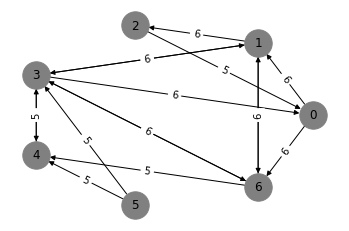

In [67]:
ipyimage('directed_sample_graph.png', width = 400)

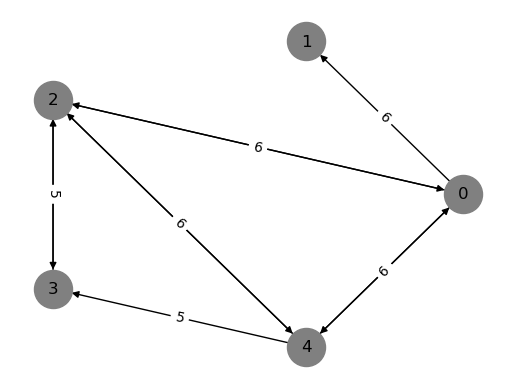

In [68]:
# Using networkX, plot your directed graph with removed vertices according to vertices_2b_removed_1
# Use circular graph layout
# Label your edges according to their weights

  # obtained from lab 5 lecture video and Lab5_Lecture_Examples_v1.5.ipynb

# Convert numpy array into directed graph networkX object
directed_adj_mat_nx = nx.from_numpy_array(directed_adj_mat_new_1, create_using=nx.DiGraph())
pos = nx.circular_layout(directed_adj_mat_nx) # Obtain positions of vertex according to circular graph layout

# Use nx.draw_networkx() to plot the graph
nx.draw_networkx(directed_adj_mat_nx, pos, with_labels = True, node_size = 750, node_color='grey')

# Use nx.get_edge_attributes() to obtain the edge weights according to adjacency matrix
labels = nx.get_edge_attributes(directed_adj_mat_nx,'weight')

# Use nx.draw_networkx_edge_labels() to label the edges with the weights
nx.draw_networkx_edge_labels(directed_adj_mat_nx, pos,edge_labels=labels)

plt.axis('off')
plt.show()

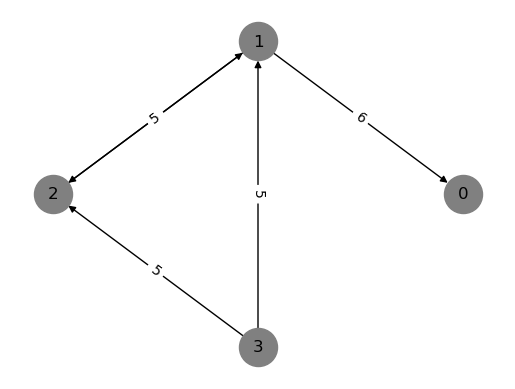

In [69]:
# Using networkX, plot your directed graph with removed vertices according to vertices_2b_removed_2
# Use circular graph layout
# Label your edges according to their weights

# YOUR CODE HERE
# Using networkX, plot your directed graph with removed vertices according to vertices_2b_removed_1
# Use circular graph layout
# Label your edges according to their weights

    # obtained from lab 5 lecture video and Lab5_Lecture_Examples_v1.5.ipynb

# Convert numpy array into directed graph networkX object
directed_adj_mat_nx = nx.from_numpy_array(directed_adj_mat_new_2, create_using=nx.DiGraph())
pos = nx.circular_layout(directed_adj_mat_nx) # Obtain positions of vertex according to circular graph layout

# Use nx.draw_networkx() to plot the graph
nx.draw_networkx(directed_adj_mat_nx, pos, with_labels = True, node_size = 750, node_color='grey')

# Use nx.get_edge_attributes() to obtain the edge weights according to adjacency matrix
labels = nx.get_edge_attributes(directed_adj_mat_nx,'weight')

# Use nx.draw_networkx_edge_labels() to label the edges with the weights
nx.draw_networkx_edge_labels(directed_adj_mat_nx, pos,edge_labels=labels)

plt.axis('off')
plt.show()

## Exercise 4: Adding a new vertex to a graph

In [71]:
# We will use the pre-existing directed graph sample earlier in the lab
# The graph has 7 vertices

directed_adj_mat_pd = pd.read_excel('directed_sample.xlsx')
directed_adj_mat_np = np.array(directed_adj_mat_pd)

In [72]:
def add_vertex(adj_mat, outgoing_edges, incoming_edges):
    # The original directed graph has 7 vertices
    # The new vertex to be added can be regarded as 8th vertex of the graph
    # You can assume that each edge being added has weight of 1

    ## get the current no. of vertices
    curr_count = adj_mat.shape[0]

    ## make new adjacency matrix with one additional row and column padded
    ## with zeroes
    adj_mat_new = np.zeros((curr_count + 1, curr_count + 1), dtype = int)

    ## reinitialize the existing vertices' incoming and outogoing edges
    adj_mat_new[:curr_count, :curr_count] = adj_mat

    ## add incoming edges
    for source in incoming_edges:
      adj_mat_new[source, curr_count] = 1

    ## add outgoing edges
    for target in outgoing_edges:
      adj_mat_new[curr_count, target] = 1

    return adj_mat_new

In [73]:
# Define outgoing and incoming edges for the new vertex to be added

outgoing_edges = [2, 3, 5]
incoming_edges = [3, 4, 6]

In [74]:
# Test your function with provided list of outgoing/incoming edges

directed_adj_mat_vertex_added = add_vertex(adj_mat = directed_adj_mat_np,
                                  outgoing_edges = outgoing_edges,
                                  incoming_edges = incoming_edges)

### Original graph image for reference

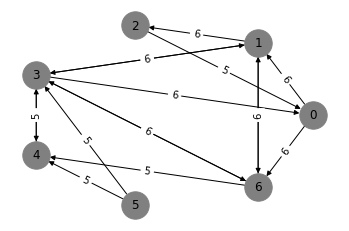

In [75]:
ipyimage('directed_sample_graph.png', width = 400)

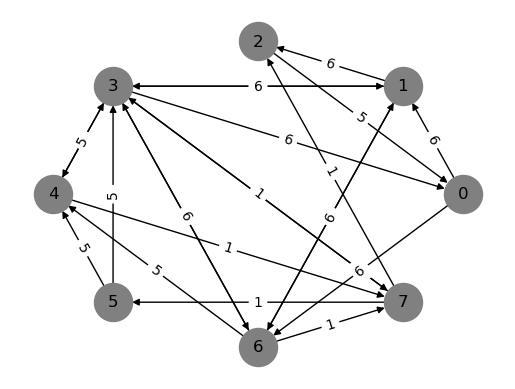

In [76]:
# Using networkX, plot your directed graph with added vertices according to outgoing_edges and incoming_edges
# Use circular graph layout
# Label your edges according to their weights

# YOUR CODE HERE

  # obtained from lab 5 lecture video and Lab5_Lecture_Examples_v1.5.ipynb

# Convert numpy array into directed graph networkX object
directed_adj_mat_nx = nx.from_numpy_array(directed_adj_mat_vertex_added, create_using=nx.DiGraph())
pos = nx.circular_layout(directed_adj_mat_nx) # Obtain positions of vertex according to circular graph layout

# Use nx.draw_networkx() to plot the graph
nx.draw_networkx(directed_adj_mat_nx, pos, with_labels = True, node_size = 750, node_color='grey')

# Use nx.get_edge_attributes() to obtain the edge weights according to adjacency matrix
labels = nx.get_edge_attributes(directed_adj_mat_nx,'weight')

# Use nx.draw_networkx_edge_labels() to label the edges with the weights
nx.draw_networkx_edge_labels(directed_adj_mat_nx, pos,edge_labels=labels)

plt.axis('off')
plt.show()

## Exercise 5: Re-wire neurons to restore behavior of C. elegans

### Note: If you wish to use the included C. elegans simulation code in lab template folder outside of EE 241 (e.g. research purpose), please cite the following paper
### Kim, J., Leahy, W., & Shlizerman, E. (2019). Neural interactome: Interactive simulation of a neuronal system. Frontiers in Computational Neuroscience, 13, 8.

In [78]:
# Load synaptic connectome and neuron classes

damaged_syn_conn_pd = pd.read_excel('connectome_syn.xlsx')
damaged_syn_conn_np = np.array(damaged_syn_conn_pd)

## Motorneurons' activities during gentle tail touch (Damaged brain)

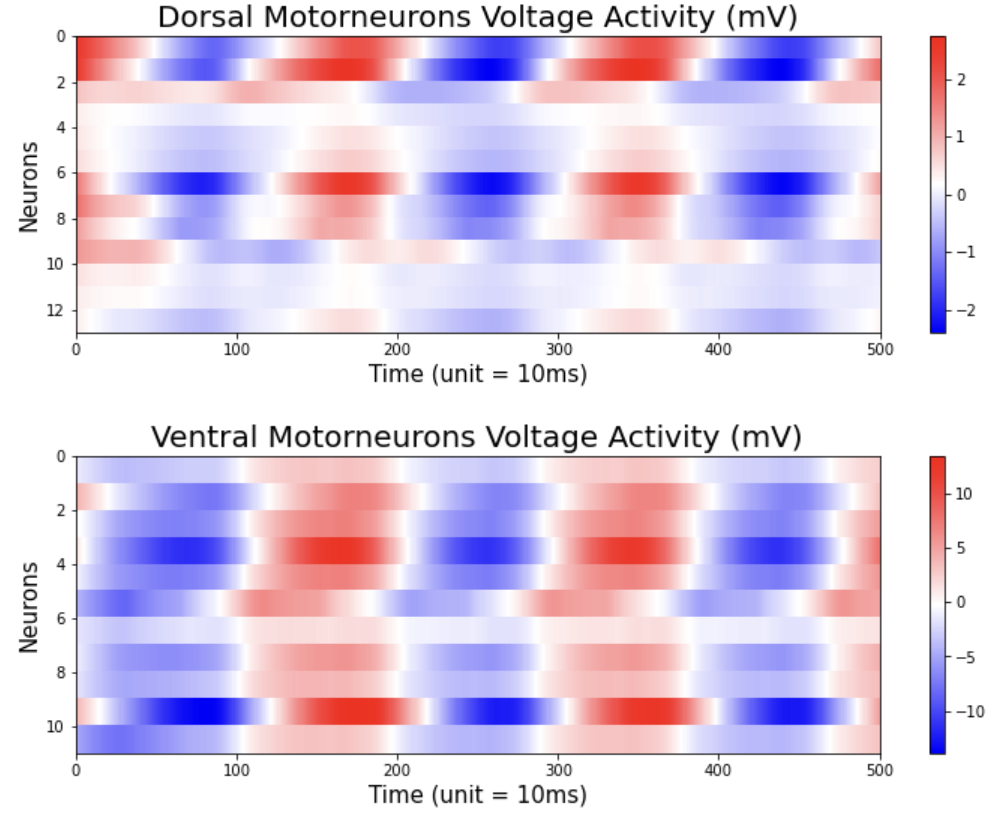

In [79]:
ipyimage('damaged_AVA_motor_activities.png', width = 450)

## Simulated body movement during gentle tail touch (Damaged brain)

In [80]:
from ipywidgets import Video

Video.from_file("escape_response_damaged.mp4", width=500, height=500)

Video(value=b'\x00\x00\x00 ftypisom\x00\x00\x02\x00isomiso2avc1mp41\x00\x00\x00\x08free\x00\x06\x01umdat\x00\x…

In [81]:
# Re-wiring instructions for AVAL and AVAR neurons

outgoing_AVAL_triples = np.load('AVAL_outgoing_triples.npy') # AVAL is the 47th vertex in the graph
incoming_AVAL_triples = np.load('AVAL_incoming_triples.npy') # AVAL is the 47th vertex in the graph

outgoing_AVAR_triples = np.load('AVAR_outgoing_triples.npy') # AVAR is the 55th vertex in the graph
incoming_AVAR_triples = np.load('AVAR_incoming_triples.npy') # AVAR is the 55th vertex in the graph

# Each row in the triple is ordered as [Source neuron index, Target neuron index, Synaptic weight]

rewiring_triples_AVAL = [outgoing_AVAL_triples, incoming_AVAL_triples]
rewiring_triples_AVAR = [outgoing_AVAR_triples, incoming_AVAR_triples]

In [82]:
def rewire_neurons(damaged_synaptic_adj_matrix, rewiring_instructions_AVAL, rewiring_instructions_AVAR):

    # YOUR CODE HERE
    # AVAL, AVAR neurons take the indices of 47, 55 respectively in the damaged_syn_conn_np
    
    # Create a copy of the damaged synaptic adjacency matrix to repair
    repaired_synaptic_adj_matrix = np.copy(damaged_synaptic_adj_matrix)

    # Rewire AVAL neuron
    AVAL_OUT = rewiring_instructions_AVAL[0]
    AVAL_IN = rewiring_instructions_AVAL[1]
    for out_triplet in AVAL_OUT:
        source, target, weight = out_triplet
        repaired_synaptic_adj_matrix[47, target] = weight
    for in_triplet in AVAL_IN:
        source, target, weight = in_triplet
        repaired_synaptic_adj_matrix[source, 47] = weight


    # Rewire AVAR neuron
    AVAR_OUT = rewiring_instructions_AVAR[0]
    AVAR_IN = rewiring_instructions_AVAR[1]
    for out_triplet in AVAR_OUT:
        source, target, weight = out_triplet
        repaired_synaptic_adj_matrix[55, target] = weight
    for in_triplet in AVAR_IN:
        source, target, weight = in_triplet
        repaired_synaptic_adj_matrix[source, 55] = weight
    
    return repaired_synaptic_adj_matrix

In [83]:
repaired_synaptic_adj_matrix = rewire_neurons(damaged_synaptic_adj_matrix = damaged_syn_conn_np,
                                              rewiring_instructions_AVAL = rewiring_triples_AVAL,
                                              rewiring_instructions_AVAR = rewiring_triples_AVAR)

In [84]:
# Test your repaired connectome

dw.network_sim.test_brain_repair(repaired_synaptic_adj_matrix)

# If successfully repaired, function will output
# 1) Motorneurons activity
# 2) Simulated body movement video with repaired brain

NameError: name 'dw' is not defined